# 🧪 LAB: Non-linear Dimensionality Reduction — t-SNE and UMAP

Over the past few weeks, we have explored how to handle non-linear relationships, mainly in the context of classification and regression tasks.

However, sometimes the first and most important step is to **visualize** the data — to gain intuition, spot structure, or detect outliers — even before any predictive modeling. You have already seen how PCA can help with this, but as we discussed this week, (ordinary) PCA is a linear method and may not capture non-linear patterns in the data effectively.

In this lab, you will learn about two popular **non-linear dimensionality reduction techniques** that are typically used for **data visualization**:  
- **t-SNE (t-distributed Stochastic Neighbor Embedding)**  
- **UMAP (Uniform Manifold Approximation and Projection)**

You will apply and compare these methods on two datasets:
- A simple biological dataset: Palmer Penguins
- A high-dimensional human genotype dataset from the 1000 Genomes Project (adapted from Diaz-Papkovich *et al.*, 2019)

---

**Collaboration Note**: This assignment is designed to support collaborative work. We encourage you to divide tasks among group members so that everyone can contribute meaningfully. Many components of the assignment can be approached in parallel or split logically across team members. Good coordination and thoughtful integration of your work will lead to a stronger final result.

---

In total, this lab assignment will be worth **100 points**.

--- 
**Submission notes**:

* Write down all group members' names, or at least the group name (if you have one and you previously provided it), in the first cell of the notebook.

* Verify that the notebook runs as expected and that all required outputs are included.


In [1]:
NAMES = "Ali Powell, Olivia Teng, Will Sutton"

## 1. Background Reading (20 points)

Begin by reading **Section 5.3: t-SNE and UMAP for High-Dimensional Data** from the [*Machine Learning Hero* book](https://www.oreilly.com/library/view/machine-learning-hero/9781837025015/), which is available through UVA’s subscription to O’Reilly.

After reading, discuss with your group and respond to the following questions:

a. **Why might we choose t-SNE or UMAP over PCA for dimensionality reduction?**  
Briefly explain the limitations of PCA, and why non-linear methods like t-SNE and UMAP can be more effective in some contexts.

b. **Summarize the strengths and weaknesses of t-SNE and UMAP.**  
What are the key differences between the two methods? In what situations might you prefer one over the other?

c. **What are the main hyperparameters of each method, and what role do they play?**  
Describe how these hyperparameters affect the behavior and output of the algorithms.


a. A big limitation of PCA is that it cannot capture non-linear relationships. It finds maximum variance orthogonal directions, so it works linearly. If our data structure is curved, or nonlinear, the flat projection of PCA would essentially squish these regions on top of each other. It also only keeps what ha s a large global variance, so smaller clusters and such would be lost. Also, a lot of groups would overlap because beause it only uses two components, so it it may only capture a small portion of variance. t-SNE and UMAP can be more effective because they can capture non-linear relationships. They visualize high-dimensional data in lower-dimensional spaces. This way, they can find hidden patterns, manifolds, and outliers in the data that PCA cannot find. Because they can preserve local similarities between data points, they can find underlying relationships that are non-linear and separate clusters that PCA would overlap or squish together. t-SNE and UMAP are a lot better for contexts to visualize high-dimensional data. Contexts like image recognition and natural language processing, where mapping similar data points in a high-dimensional space are close together in a 2 or 3D representation, would be highly effective to use t-SNE and UMAP. 

b. t-SNE and UMAP both reduce high dimensional data into fewer dimensions, usually to visualize different patterns and groups. The main differences are speed and how they keep relationships between observations. t-SNE is good at keeping local neighborhoods and finding small groups of similar observations, however, it can be slower on larger datasets, and cluster sizes and distances produced might be misleading. It’s also sensitive to settings and initialization. UMAP is usually the faster option, it also scales well to large datasets, and can often keep more of the broader structure while keeping local neighborhoods. It is also able to map new observations into an existing framework. It however is also sensitive to settings and initialization. It can create apparent clusters, and distances between groups made still aren’t guaranteed to actually reflect the original data. The difference overall is their approach, where t-SNE tries to match similarity probabilities between observations in the original data and the reduced map. Where UMAP builds a network that connects neighboring observations and then tries to preserve that network in fewer dimensions. I think it’s a good thing to point out that neither method proves that distinct clusters exist. 

c. For t-SNE, the main hyperparameter is perplexity. It basically controls how many nearby points t-SNE pays attention to when creating the lower-dimensional map. A lower perplexity focuses more on small, local clusters, while a higher perplexity looks at a wider neighborhood and can show broader patterns in the data. The reading also mentions n_iter, which controls how long the algorithm runs, and n_components, which controls how many dimensions the final output has. These two are more general method settings while perplexity has a larger effect on how this data is represented. 

For UMAP, the two main hyperparameters are n_neighbors and min_dist. n_neighbors controls how much UMAP focuses on local clusters compared to the overall structure of the data. Smaller values are able to focus more on nearby points, while larger values take more of the bigger picture into account. min_dist controls how close these points are allowed to be in the final visualization, so smaller values create tighter clusters and larger values spread the points out more.



## 2. Experiment with the Palmer Penguins Dataset (Toy Example) (50 points)

To get hands-on experience, you will begin by applying dimensionality reduction techniques to a small and interpretable dataset: Palmer Penguins.

Before you begin coding, read the official documentation for the following methods:

- [PCA](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html) — from `sklearn.decomposition`
- [t-SNE](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html) — from `sklearn.manifold`
- [UMAP](https://umap-learn.readthedocs.io/en/latest/basic_usage.html) — from the `umap-learn` package

After reviewing the documentation, complete the following tasks:

a. Load the Palmer Penguins dataset as demonstrated in the [UMAP documentation](https://umap-learn.readthedocs.io/en/latest/basic_usage.html#penguin-data).  

Select the following numerical features:

- `bill_length_mm`  
- `bill_depth_mm`  
- `flipper_length_mm`  
- `body_mass_g`

Then, **standardize** these features so that each has zero mean and unit variance.

In [4]:
import numpy as np
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
%matplotlib inline

# style choice
sns.set(style="white", context="notebook", rc={"figure.figsize": (14, 10)})

# clean data and select the features we want
penguins = sns.load_dataset("penguins").dropna().copy()

features = [
    "bill_length_mm",
    "bill_depth_mm",
    "flipper_length_mm",
    "body_mass_g",
]

penguin_data = penguins.loc[:, features].to_numpy()

scaled_penguin_data = StandardScaler().fit_transform(penguin_data)

reducer = umap.UMAP()

# lets look
print("Penguins-", penguins.shape)
print("Scaled features-", scaled_penguin_data.shape)


Penguins- (333, 7)
Scaled features- (333, 4)


b. Apply **PCA**, **t-SNE**, and **UMAP** to reduce the selected features to **2 dimensions**.

Then, for each method:
- Create a **scatter plot** of the 2D projection.
- Use a different color to represent each **species** in the dataset.

This will help you visually assess how well each method separates the species in the reduced space.

*N.B.* You may need to first install `UMAP-learn`. Follow the [documentation](https://umap-learn.readthedocs.io/en/latest/index.html) for that.

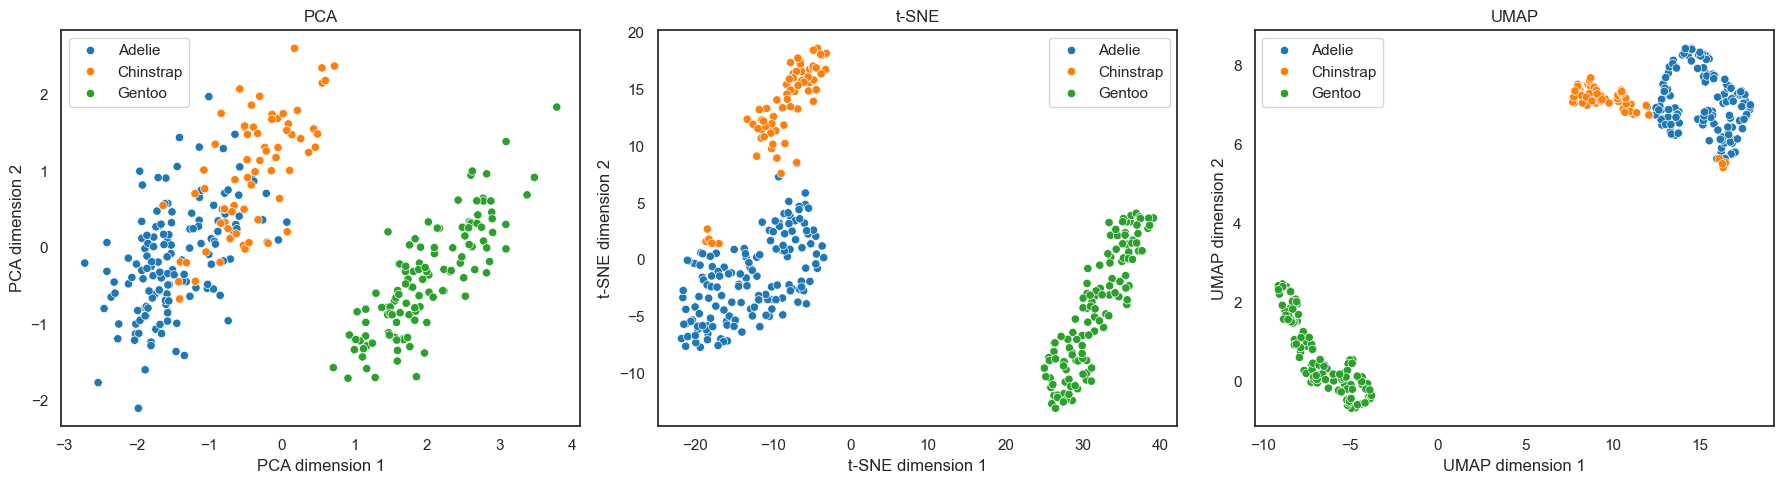

In [5]:
# YOUR CODE HERE

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap
import matplotlib.pyplot as plt
import seaborn as sns

# apply each method to the standardized featuress
pca_embedding = PCA(n_components=2).fit_transform(scaled_penguin_data)

tsne_embedding = TSNE(
    n_components=2,
    random_state=42
).fit_transform(scaled_penguin_data)

umap_embedding = umap.UMAP(
    n_components=2,
    random_state=42,
    n_jobs=1
).fit_transform(scaled_penguin_data)

# colorful penguins :)
palette = {
    "Adelie": "tab:blue",
    "Chinstrap": "tab:orange",
    "Gentoo": "tab:green"
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, name, embedding in zip(
    axes,
    ["PCA", "t-SNE", "UMAP"],
    [pca_embedding, tsne_embedding, umap_embedding]
):
    sns.scatterplot(
        x=embedding[:, 0],
        y=embedding[:, 1],
        hue=penguins["species"].to_numpy(),
        palette=palette,
        ax=ax
    )
    ax.set_title(name)
    ax.set_xlabel(f"{name} dimension 1")
    ax.set_ylabel(f"{name} dimension 2")

plt.tight_layout()
plt.show()

c. Analyze the resulting plots and describe the main patterns you observe.

- Which method produces the most visually separable clusters?
- Are there any species that overlap in one method but not in others?
- What might explain these differences in how the data is projected?

Elaborate on your observations and compare the strengths and limitations of each method based on this toy example.


YOUR TEXT HERE

d. For **t-SNE** and **UMAP**, explore how different hyperparameter settings affect the resulting 2D projections.

- For **t-SNE**, vary the `perplexity` parameter (e.g., 5, 30, 50).
- For **UMAP**, vary the `n_neighbors` parameter (e.g., 5, 15, 50) and optionally `min_dist`.
- Keep `random_state` fixed across all runs so that differences between projections are due primarily to changes in the hyperparameters rather than random initialization.

For each configuration:
- Plot the resulting 2D projection.
- Use color to represent species.

In [ ]:
# YOUR CODE HERE

After generating the plots, describe the main changes you observe in the visualizations:
- How do the clusters shift, stretch, or separate as hyperparameters change?
- Which settings appear to better preserve the structure of the data?

Elaborate on your observations and support your discussion with specific visual examples.

YOUR TEXT HERE

## 3. Apply to Real Data (1000 Genomes Subset) (25 points)

Your goal in this section is to try to create a figure similar to Figure 1 of the Diaz-Papkovich *et al.* (2019) paper, using a subset of genotype data from the 1000 Genomes Project.

To do so, complete the following steps:

a. Load the genotype dataset accompanying this lab, where each row corresponds to an individual, and each column to a genetic variant. Load also the provided population labels for each individual. 

b. **Standardize** the features (i.e., transform the genotype values to have zero mean and unit variance).

c. Apply **PCA**, **t-SNE**, and **UMAP** to reduce the data to 2 dimensions. You may use the default values for the rest of hyperparameters in these techniques. 

d. Create **scatter plots** of the resulting projections, coloring each point according to its **population group**.

e. Reflect on the following questions:
- Explain what you observe in each case. Additionally, which method appears to provide the best visual separation of the population into distinct groups? Elaborate on why this might be the case, based on what you know about each method.
- What changes if you first reduce the data to the **top 25 PCA components**, and then apply t-SNE or UMAP?
- In your opinion, what are the trade-offs between **interpretability** (e.g., preservation of local and global structure) and **performance** (e.g., visual separation of known populations and computational time) when using these dimensionality reduction methods?

Please elaborate on your answers and use the plots to support your discussion.

In [1]:
# YOUR CODE HERE
#A: Load data row = individual, column = genetic variant, population labels
import numpy as np
import matplotlib.pyplot as plt

X_gen = np.load("genome_data_lab3.npy").astype(float)
with open("population_labels_lab3.txt") as f:
    pops = np.array(f.read().split())
print("genotype matrix:", X_gen.shape, "| labels:", pops.shape, "| populations:", len(np.unique(pops)))
print("distinct genotype codes:", np.unique(X_gen))

#b: Standardize
from sklearn.preprocessing import StandardScaler
X_gen_std = StandardScaler().fit_transform(X_gen)

genotype matrix: (3450, 868) | labels: (3450,) | populations: 26
distinct genotype codes: [-1.  0.  1.  2.]


## 4. Collaboration Reflection (5 points)

As a group, identify **one specific challenge or inefficiency** you encountered while working on this lab. In 3–5 sentences:

1. Briefly describe what happened and how it affected your work.
2. Identify one concrete action your group will take to avoid or better manage this issue in the next lab.

If your group encountered no major problem, identify one aspect of your collaboration that could still be improved.

YOUR TEXT HERE